In [1]:
# data_loader.py
import numpy as np

def data_loader():
    X_train = np.load('../datasets/processed/X_train.npy', mmap_mode='r')
    y_train = np.load('../datasets/processed/y_train.npy', mmap_mode='r')
    X_val = np.load('../datasets/processed/X_val.npy', mmap_mode='r')
    y_val = np.load('../datasets/processed/y_val.npy', mmap_mode='r')
    X_test = np.load('../datasets/processed/X_test.npy', mmap_mode='r')
    y_test = np.load('../datasets/processed/y_test.npy', mmap_mode='r')
    classes = np.load('../datasets/processed/classes.npy', allow_pickle=True)
    return X_train, y_train, X_val, y_val, X_test, y_test, classes

In [2]:
# model_builder.py
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

def build_cnn_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

In [3]:
# === Load Data ===
X_train, y_train, X_val, y_val, X_test, y_test, classes = data_loader()

X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

print("Shape of y_train loaded from file:", y_train.shape)
print("Shape of y_val loaded from file:", y_val.shape)

num_classes = len(classes)
input_shape = X_train.shape[1:] # e.g., (130, 130, 3)

Shape of y_train loaded from file: (7789, 130)
Shape of y_val loaded from file: (974, 130)


In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [5]:
# === Preprocessing Function ===
def preprocess_dataset(X, y, num_classes, batch_size=32, shuffle=True):
    # REMOVE this line entirely, as y is already one-hot encoded:
    # y = y.astype('int32')

    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(X))

    def _preprocess(x, y):
        x = tf.cast(x, tf.float32) / 255.0
        # CHANGE this line:
        y = tf.cast(y, tf.float32) # Just cast y to float32, it's already one-hot.
        # REMOVE this line entirely:
        # y = tf.one_hot(y, num_classes)
        return x, y

    ds = ds.map(_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [6]:
# === Prepare tf.data Datasets ===
train_ds = preprocess_dataset(X_train, y_train, num_classes)
val_ds = preprocess_dataset(X_val, y_val, num_classes, shuffle=False)
test_ds = preprocess_dataset(X_test, y_test, num_classes, shuffle=False)

In [7]:
# === Build & Compile Model ===
model = build_cnn_model(input_shape, num_classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\praka\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 130)            │        33,410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,550,338 (24.99 MB)

 Trainable params: 6,549,890 (24.99 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# === Define Callbacks ===
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('models/best_anime_model.h5', save_best_only=True)
]

In [9]:
# === Train Model ===
history = model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=callbacks)

Epoch 1/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.0066 - loss: 5.7143

244/244 ━━━━━━━━━━━━━━━━━━━━ 133s 478ms/step - accuracy: 0.0066 - loss: 5.7118 - val_accuracy: 0.0103 - val_loss: 8.4523
Epoch 2/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.0060 - loss: 4.8904

244/244 ━━━━━━━━━━━━━━━━━━━━ 116s 476ms/step - accuracy: 0.0060 - loss: 4.8904 - val_accuracy: 0.0051 - val_loss: 4.8703
Epoch 3/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 113s 464ms/step - accuracy: 0.0076 - loss: 4.8789 - val_accuracy: 0.0041 - val_loss: 4.8766
Epoch 4/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 116s 474ms/step - accuracy: 0.0065 - loss: 4.8675 - val_accuracy: 0.0021 - val_loss: 4.8730
Epoch 5/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 123s 505ms/step - accuracy: 0.0089 - loss: 4.8667 - val_accuracy: 0.0062 - val_loss: 4.8742
Epoch 6/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 108s 441ms/step - accuracy: 0.0109 - loss: 4.8710 - val_accuracy: 0.0021 - val_loss: 4.8753
Epoch 7/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 104s 427ms/step - accuracy: 0.0100 - loss: 4.8669 - val_accuracy: 0.0021 - val_loss: 4.8764


In [10]:
# === Evaluate on Test Set ===
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.0064 - loss: 4.8709

Test Accuracy: 0.0041


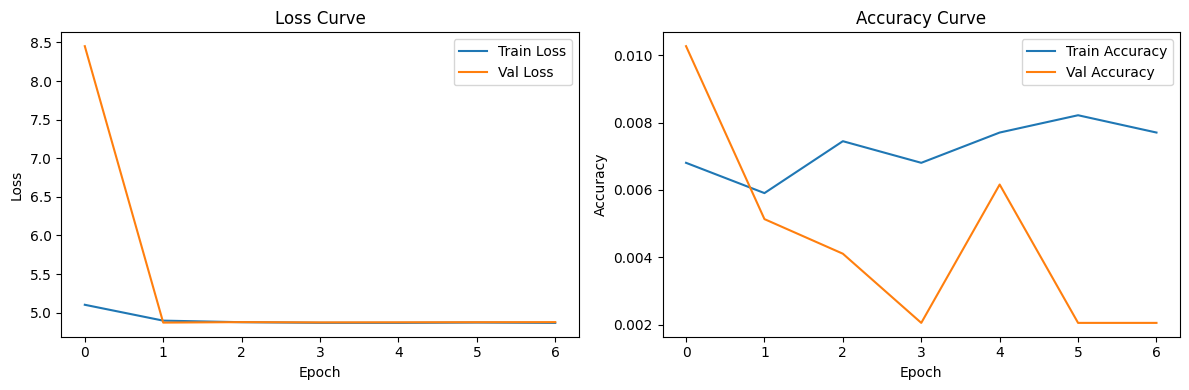

In [11]:
# === Plot Training History ===
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()